# Survived Predict with Artifical Neural Networks

Hi everybody! This kernel I'm gonna analyze Titanic Disaster Dataset by using ANN(Artifical Neural Network) I'm gonna use the Python language. I hope it's benefit for you. If this kernel is useful for you, please don't forget upvote it. I will be waiting your comment this kernel. Your comment is important in order to improving myself. So Let's go! :)

<img src="https://i.milliyet.com.tr/MolatikDetayBig/2020/04/14/fft371_mf33115214.Jpeg"/>


## CONTENTS

[1. Libraries](#1) <br/>
[2. Exploratory Data Analysis](#2) <br/>
[3. Preparing Data](#3) <br/>
[4. Train and Test Split](#4) <br/>
[5. Create Artifical Neural Network Model](#5) <br/>
[6. Model Evaluation using Confusion Matrix](#6) <br/>
[7. Conclusion](#7)

<a id="1"></a>
## Libraries

You can find the libraries which I use. :)

In [1]:
# EDA and Preparing Data libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Spliting data and creating model libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.models import Sequential #initialize neural network library
from keras.layers import Dense #build our layers library

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Using TensorFlow backend.


/kaggle/input/titanic/train.csv
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv


<a id="2"></a>
## Exploratory Data Analysis


In this section, We will analyze feature of disaster data. We will visualize our datas and will realize some information extractions. 

In [2]:
data_train = pd.read_csv("/kaggle/input/titanic/train.csv")
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The section code in above, You can find some information. There are 12 feature in the disaster data. It has information about 891 people. Five feature are integer type and other five feature are object type. Lastly, two feature are float type. Some features contain missing value.  

<a id="2.1.1"></a>
#### Survived

We can observe number of death more than number of survive. Well Is number of death/survived related to passenger class? 

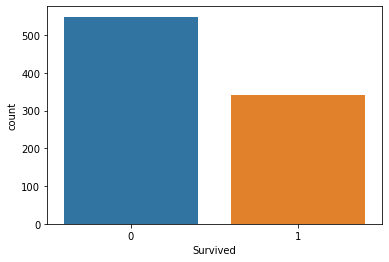

In [4]:
sns.countplot(data_train["Survived"])
plt.show()

<a id="2.2.2"></a>
#### Pclass

Waoow, There are the most third class passenger. 

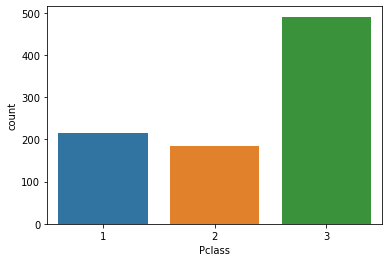

In [5]:
sns.countplot(data_train["Pclass"])

<a id="2.2.3"></a>
#### Title / Name



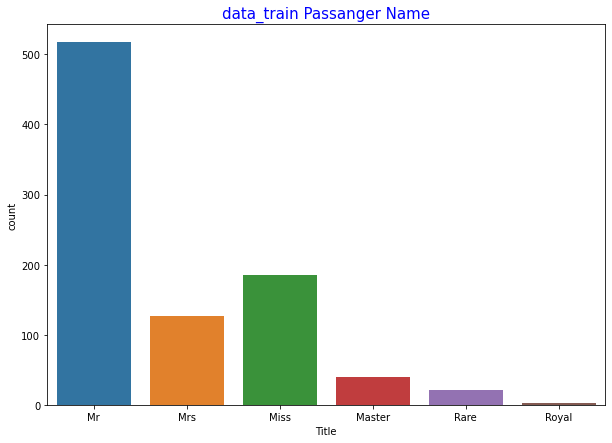

In [6]:
data_train['Title'] = data_train.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

data_train['Title'] = data_train['Title'].replace(['Lady', 'Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')
data_train['Title'] = data_train['Title'].replace(['Countess', 'Lady', 'Sir'], 'Royal')
data_train['Title'] = data_train['Title'].replace('Mlle', 'Miss')
data_train['Title'] = data_train['Title'].replace('Ms', 'Miss')
data_train['Title'] = data_train['Title'].replace('Mme', 'Mrs')

plt.figure(figsize=(10,7))
sns.countplot(data_train.Title)
plt.title("data_train Passanger Name",color = 'blue',fontsize=15)
plt.show()

#### Sex

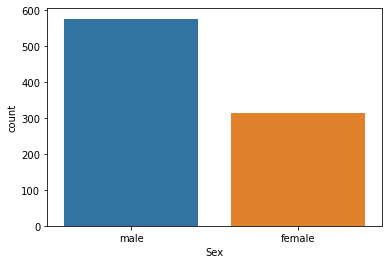

In [7]:
sns.countplot(data_train["Sex"])

/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:728: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


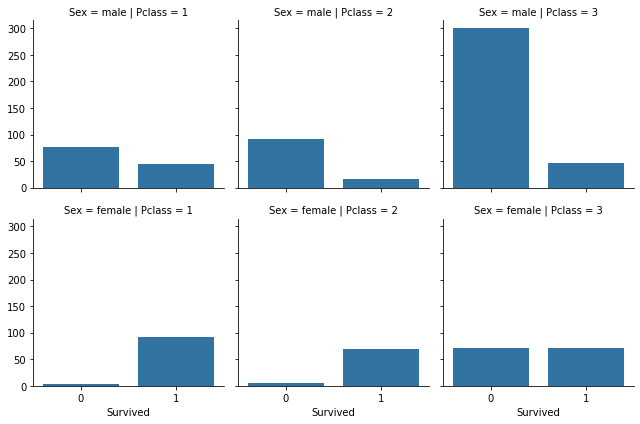

In [8]:
g = sns.FacetGrid(data_train,row="Sex",col="Pclass")
g.map(sns.countplot,"Survived")
plt.show()

In the graphs above, we see survived number according to sex and passenger class. We can observe death man number more than death woman. Also, passanger class is effective in the death number. You know the disaster. First class passengers are saved, Third class passengers are sunk into water. :(

#### Age

In [9]:
data_train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

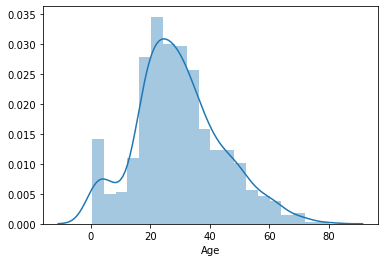

In [10]:
sns.distplot(data_train["Age"])

#### SibSp

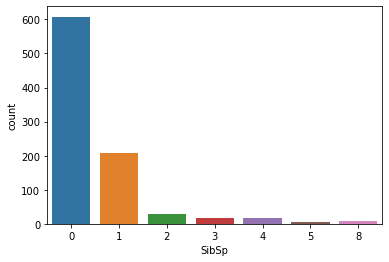

In [11]:
sns.countplot(data_train["SibSp"])

#### Parch

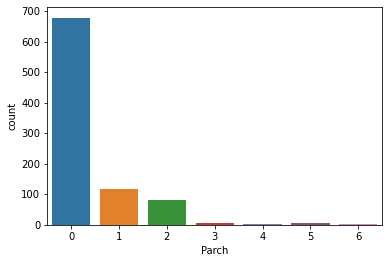

In [12]:
sns.countplot(data_train["Parch"])

As we see SibSp and Parch features. The number of alone passangers are quite more. Parch and SibSp represent parent, child(Parch) and sibling,spouse(SibSp). 

#### Fare

In [13]:
data_train["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

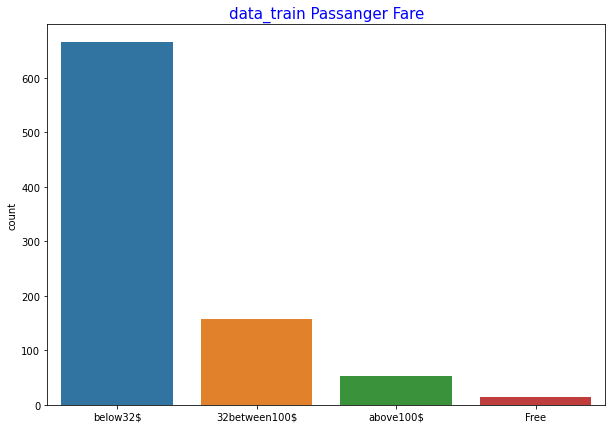

In [14]:
fare = ['above100$' if i>=100 else '32between100$' if (i<100 and i>=32) else 'Free' if i==0 else 'below32$' for i in data_train["Fare"]]
plt.figure(figsize=(10,7))
sns.countplot(fare)
plt.title("data_train Passanger Fare",color = 'blue',fontsize=15)
plt.show()

Mean train fare is 32$. In the graph above we see most passanger who buy ticket below 32$. Probably this passangers can be 3th. class. 

#### Embarked

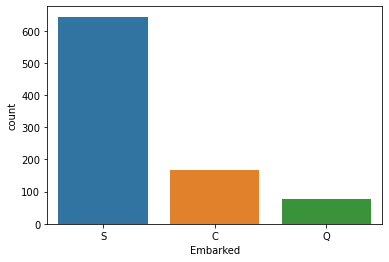

In [15]:
sns.countplot(data_train["Embarked"])

<a id="3"></a>
## Preparing Data

In this part, We gonna prepare train and test dataset.

### Train Dataset

In [16]:
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [17]:
#missing value
print(pd.isnull(data_train).sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64


In [18]:
# drop name and ticket
data_train = data_train.drop(["PassengerId","Name","Ticket"],axis=1)

# Sex
data_train["Sex"] = data_train["Sex"].replace("male",1)
data_train["Sex"] = data_train["Sex"].replace("female",2)

# Age
data_train["Age"] = data_train["Age"].replace(np.nan,data_train["Age"].median())

# Fare
data_train["Fare"] = data_train["Fare"].replace(np.nan,data_train["Fare"].median())

# Cabin
data_train.loc[data_train["Cabin"].str[0] == 'A', 'Cabin'] = 1
data_train.loc[data_train["Cabin"].str[0] == 'B', 'Cabin'] = 2
data_train.loc[data_train["Cabin"].str[0] == 'C', 'Cabin'] = 3
data_train.loc[data_train["Cabin"].str[0] == 'D', 'Cabin'] = 4
data_train.loc[data_train["Cabin"].str[0] == 'E', 'Cabin'] = 5
data_train.loc[data_train["Cabin"].str[0] == 'F', 'Cabin'] = 6
data_train.loc[data_train["Cabin"].str[0] == 'G', 'Cabin'] = 7
data_train.loc[data_train["Cabin"].str[0] == 'T', 'Cabin'] = 8
data_train["Cabin"] = data_train["Cabin"].fillna(data_train["Cabin"].mean())

# Embarked
data_train["Embarked"] = data_train["Embarked"].replace("S",1)
data_train["Embarked"] = data_train["Embarked"].replace("C",2)
data_train["Embarked"] = data_train["Embarked"].replace("Q",3)
data_train["Embarked"] = data_train["Embarked"].replace(np.nan,data_train["Embarked"].median())

# Title
data_train["Title"] = data_train["Title"].replace("Mr",1)
data_train["Title"] = data_train["Title"].replace("Mrs",2)
data_train["Title"] = data_train["Title"].replace("Miss",3)
data_train["Title"] = data_train["Title"].replace("Master",4)
data_train["Title"] = data_train["Title"].replace("Rare",5)
data_train["Title"] = data_train["Title"].replace("Royal",6)

#Family Size
data_train['FamilySize'] = data_train['SibSp'] + data_train['Parch']

data_train.drop(["SibSp","Parch"],axis=1,inplace=True)

### Test Dataset

In [19]:
data_test = pd.read_csv("/kaggle/input/titanic/test.csv")
data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [20]:
print(pd.isnull(data_test).sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [21]:
#Title
data_test['Title'] = data_test.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

data_test['Title'] = data_test['Title'].replace(['Lady', 'Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')
data_test['Title'] = data_test['Title'].replace(['Countess', 'Lady', 'Sir'], 'Royal')
data_test['Title'] = data_test['Title'].replace('Mlle', 'Miss')
data_test['Title'] = data_test['Title'].replace('Ms', 'Miss')
data_test['Title'] = data_test['Title'].replace('Mme', 'Mrs')

# Sex
data_test["Sex"] = data_test["Sex"].replace("male",1)
data_test["Sex"] = data_test["Sex"].replace("female",2)

# Age
data_test["Age"] = data_test["Age"].replace(np.nan,data_test["Age"].median())

# Fare
data_test["Fare"] = data_test["Fare"].replace(np.nan,data_test["Fare"].median())

# Cabin
data_test.loc[data_test["Cabin"].str[0] == 'A', 'Cabin'] = 1
data_test.loc[data_test["Cabin"].str[0] == 'B', 'Cabin'] = 2
data_test.loc[data_test["Cabin"].str[0] == 'C', 'Cabin'] = 3
data_test.loc[data_test["Cabin"].str[0] == 'D', 'Cabin'] = 4
data_test.loc[data_test["Cabin"].str[0] == 'E', 'Cabin'] = 5
data_test.loc[data_test["Cabin"].str[0] == 'F', 'Cabin'] = 6
data_test.loc[data_test["Cabin"].str[0] == 'G', 'Cabin'] = 7
data_test.loc[data_test["Cabin"].astype(str).str[0] == 'T', 'Cabin'] = 8
data_test["Cabin"] = data_test["Cabin"].fillna(int(data_test["Cabin"].mean()))

# Embarked
data_test["Embarked"] = data_test["Embarked"].replace("S",1)
data_test["Embarked"] = data_test["Embarked"].replace("C",2)
data_test["Embarked"] = data_test["Embarked"].replace("Q",3)

# Title
data_test["Title"] = data_test["Title"].replace("Mr",1)
data_test["Title"] = data_test["Title"].replace("Mrs",2)
data_test["Title"] = data_test["Title"].replace("Miss",3)
data_test["Title"] = data_test["Title"].replace("Master",4)
data_test["Title"] = data_test["Title"].replace("Rare",5)
data_test["Title"] = data_test["Title"].replace("Royal",6)

#Family Size
data_test['FamilySize'] = data_test['SibSp'] + data_test['Parch']

# drop passenger id, name,ticket, sibsp and parch
data_test_x = data_test.drop(["PassengerId","Name","Ticket","SibSp","Parch"],axis=1)

<a id="4"></a>
## Train and Test Split

Our train data splitted as train and test data in order to educate correctly. Train data creates %80 percent of main train data and test data creates %20 percent of main train data. In the below, you see number of passenger train and test datas. You can set percentage datas according to yourself model.

In [22]:
X = data_train.drop(["Survived"],axis=1)
Y = data_train["Survived"]
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)
print("x_train shape: ",x_train.shape)
print("y_train shape: ",y_train.shape)
print("x_test shape: ",x_test.shape)
print("y_test shape: ",y_test.shape)

x_train shape:  (712, 8)
y_train shape:  (712,)
x_test shape:  (179, 8)
y_test shape:  (179,)


<a id="5"></a>
## Create Artifical Neural Network Model

I used to artifical neural network model. I wrote about deep learning beginner tutorial on Kaggle. You can reach it when you click [this](https://www.kaggle.com/ecemboluk/deep-learning-tutorial-on-sign-language-digits). I used to 6 layer together input and output layer. My model has 4 hidden layer. My hidden layers contain 60 units in total. As activation function I prefered relu. Because it is more faster than other activation function. I prefer adam algorithm as optimizer algorithm. Epochs, layer number, unit number are hyperparameters. Nobody don't know which values is true for their model. You can find this by trying. :)

In [23]:
classifier = Sequential() # initialize neural network
classifier.add(Dense(units = 128, activation = 'relu', input_dim = X.shape[1]))
classifier.add(Dense(units = 32, activation = 'relu'))
classifier.add(Dense(units = 16, activation = 'relu'))
classifier.add(Dense(units = 8, activation = 'relu'))
classifier.add(Dense(units = 4, activation = 'relu'))
classifier.add(Dense(units = 1, activation = 'sigmoid')) #output layer
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model = classifier.fit(x_train,y_train,epochs=600)
mean = np.mean(model.history['accuracy'])
print("Accuracy mean: "+ str(mean))

Epoch 1/600
712/712 [==============================] - 1s 903us/step - loss: 0.6321 - accuracy: 0.6517
Epoch 2/600
712/712 [==============================] - 0s 65us/step - loss: 0.6041 - accuracy: 0.6882
Epoch 3/600
712/712 [==============================] - 0s 68us/step - loss: 0.5992 - accuracy: 0.6938
Epoch 4/600
712/712 [==============================] - 0s 75us/step - loss: 0.5944 - accuracy: 0.6938
Epoch 5/600
712/712 [==============================] - 0s 74us/step - loss: 0.5869 - accuracy: 0.7079
Epoch 6/600
712/712 [==============================] - 0s 67us/step - loss: 0.5775 - accuracy: 0.7205
Epoch 7/600
712/712 [==============================] - 0s 67us/step - loss: 0.5654 - accuracy: 0.7331
Epoch 8/600
712/712 [==============================] - 0s 72us/step - loss: 0.5452 - accuracy: 0.7346
Epoch 9/600
712/712 [==============================] - 0s 89us/step - loss: 0.5349 - accuracy: 0.7444
Epoch 10/600
712/712 [==============================] - 0s 66us/step - loss: 0.54

<a id="6"></a>
## Model Evaluation using Confusion Matrix

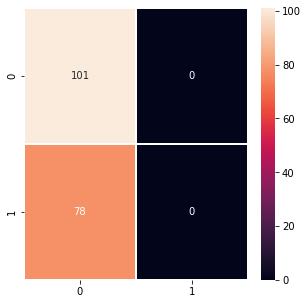

In [24]:
y_predict = classifier.predict(x_test)
cm = confusion_matrix(y_test,np.argmax(y_predict, axis=1))

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", linewidths=.5, ax=ax)

## Conclusion

Artifical Neural Netwok succeed quite prediction survived.    

In [25]:
ids = data_test['PassengerId']
predict = classifier.predict(data_test_x)

#set the output as a dataframe and convert to csv file named submission.csv
output = pd.DataFrame({ 'PassengerId' : ids, 'Survived': np.argmax(predict,axis=1)})
output.to_csv('submission.csv', index=False)